In [1]:
library(tidyverse)
library(repr)
library(tidymodels)
library(cowplot)
options(repr.matrix.max.rows = 6)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

# Investigating the Relationship Between Playtime, Experience, and Subscription in Online Gaming Data
## DSCI100 
### Group 38 - Eugene, Harleen, Tim


### Introduction

WRITE INTRODUCTION HERE --- 

## Methods

### Data Wrangling & Cleaning
We performed a complete workflow consisting of data loading, cleaning, exploratory data analysis, modeling, and visualization. The analysis was conducted in R using the tidyverse and tidymodels packages.

We began by loading the player dataset containing demographic and behavioural variables. This dataset forms the basis of our predictive modeling. Next, to prepare the dataset for analysis, we selected only variables relevant to predicting subscription status. We removed missing values and converted categorical variables into factors, ensuring the dataset met the assumptions required for modeling.

In [2]:
players <- read_csv('players.csv')
players

players <- players |>
  mutate(
    experience = factor(experience, levels = c("Beginner", "Amateur", "Regular", "Pro", "Veteran"), ordered = TRUE),
   subscribe = factor(subscribe,levels = c(FALSE, TRUE),
      labels = c("no", "yes"))
  )
      
players_wrangled <- players |>
    rename(age = Age, hashed_email = hashedEmail) |>
    select(age, played_hours, experience, subscribe) |>
    drop_na(age, played_hours, experience, subscribe)
players_wrangled



Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


age,played_hours,experience,subscribe
<dbl>,<dbl>,<ord>,<fct>
9,30.3,Pro,yes
17,3.8,Veteran,yes
17,0.0,Veteran,no
⋮,⋮,⋮,⋮
22,0.3,Veteran,no
57,0.0,Amateur,no
17,2.3,Amateur,no


### Summary Statistics for Exploratory Data Analysis

To understand the structure and distribution of the dataset, we computed summaries aligned with our planned analysis. These summaries helped us identify general player trends and assess relationships between predictors and subscription status.

In [3]:
players_summary <- players_wrangled |>
  summarise(mean_age = mean(age, na.rm = TRUE),
    mean_hours = mean(played_hours),
    number_of_players = n())
players_summary 

players_subscribed <- players_wrangled |>
  group_by(subscribe) |>
  summarise(
    mean_age = mean(age, na.rm = TRUE),
    mean_hours = mean(played_hours),
    n = n(), .groups = "drop")
players_subscribed


experience_subscription_summary <- players_wrangled |>
  group_by(experience) |>
  summarise(
    subscription_rate = (mean(subscribe == TRUE)*100),
    number_of_players = n(),
    .groups = "drop")

experience_subscription_summary


mean_age,mean_hours,number_of_players
<dbl>,<dbl>,<int>
21.13918,5.904639,194


subscribe,mean_age,mean_hours,n
<fct>,<dbl>,<dbl>,<int>
no,23.7500,0.5019231,52
yes,20.1831,7.8830986,142


experience,subscription_rate,number_of_players
<ord>,<dbl>,<int>
Beginner,0,35
Amateur,0,63
Regular,0,35
Pro,0,13
Veteran,0,48


The summary statistics provide an initial understanding of how demographic and behavioural characteristics differ between players who subscribe and those who do not. Across the full dataset (n = 196), players have an average age of approximately 21.1 years and play an average of 5.85 total hours.  

When comparing subscription groups, non-subscribers tend to be older on average (23.75 years) but play very few hours (0.50 hours), while subscribers are slightly younger (20.18 years) and play substantially more (7.78 hours). This pattern suggests that playtime may be a more important driver of subscription behaviour than age. 

Examining experience levels further supports this trend: subscription rates are highest among Regular (80.6%) and Beginner players (77.1%), while Veteran and Amateur players subscribe at somewhat lower rates (68.8% and 71.4%, respectively). These differences indicate that both gameplay experience and engagement may influence the likelihood of subscribing, motivating the need for visual exploration to better understand these relationships.

### Exploratory Visualization


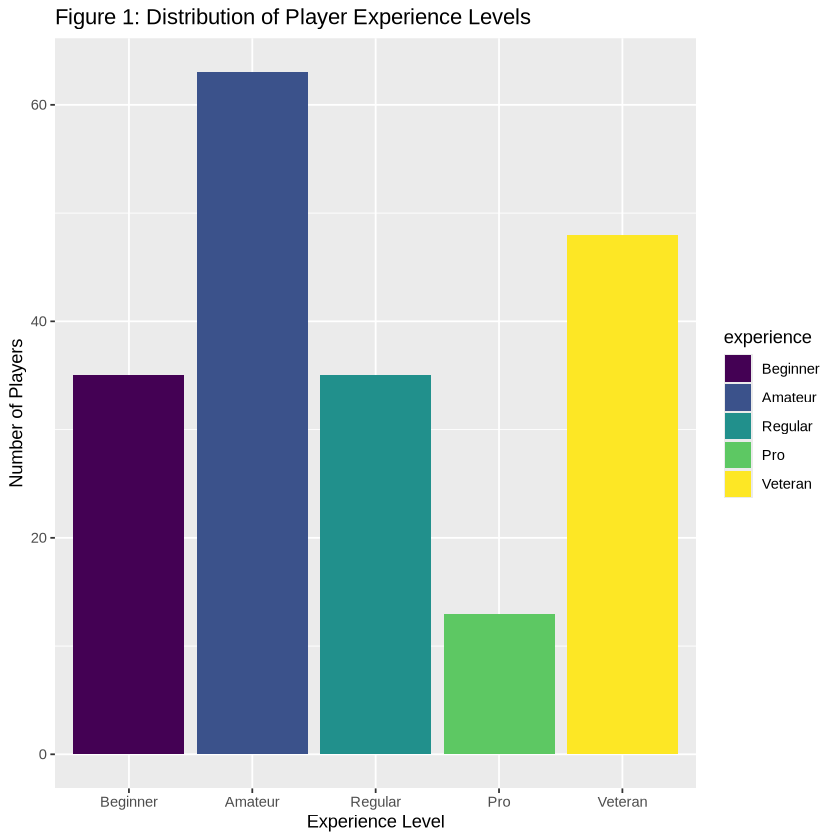

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


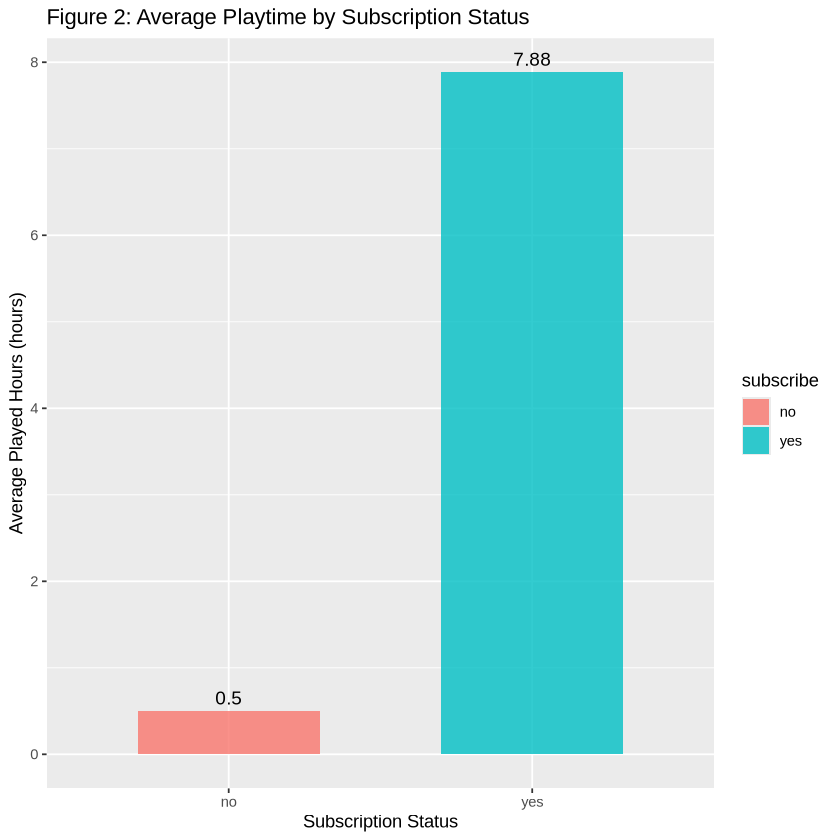

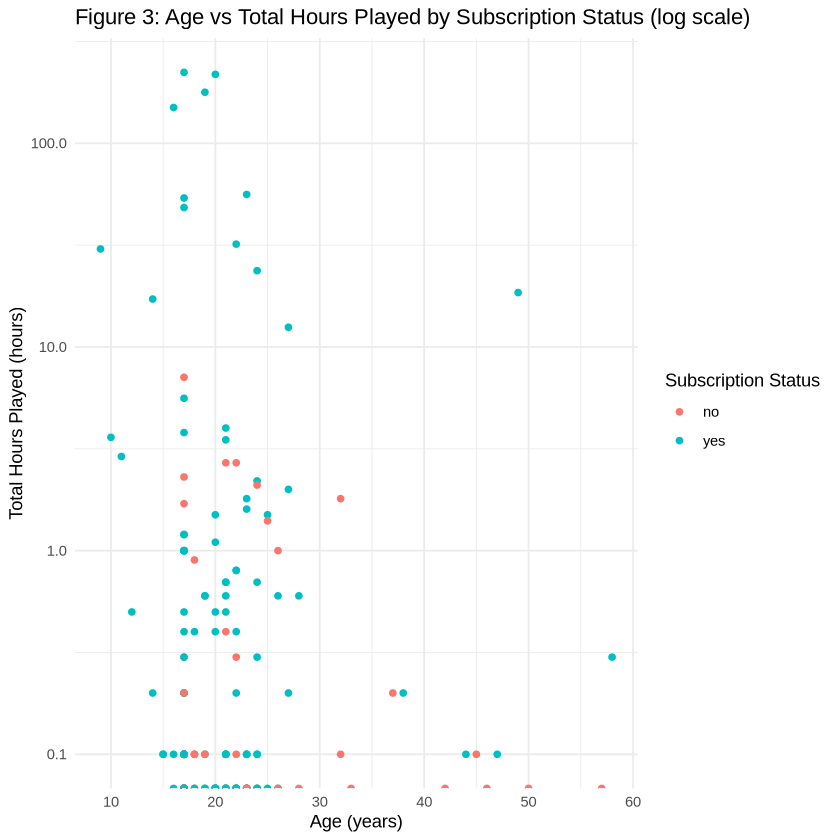

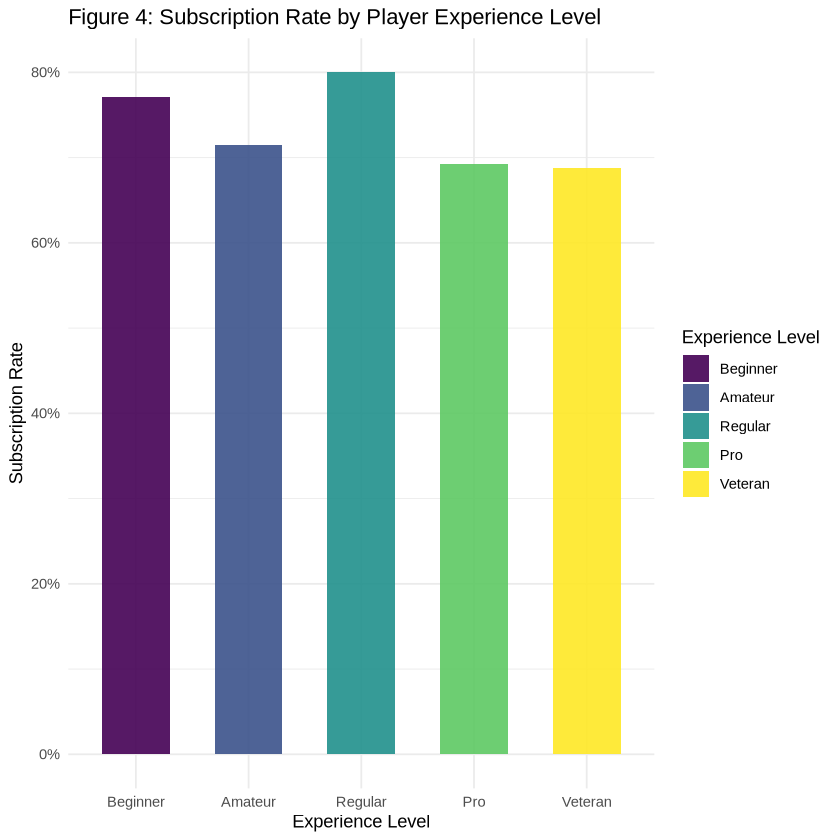

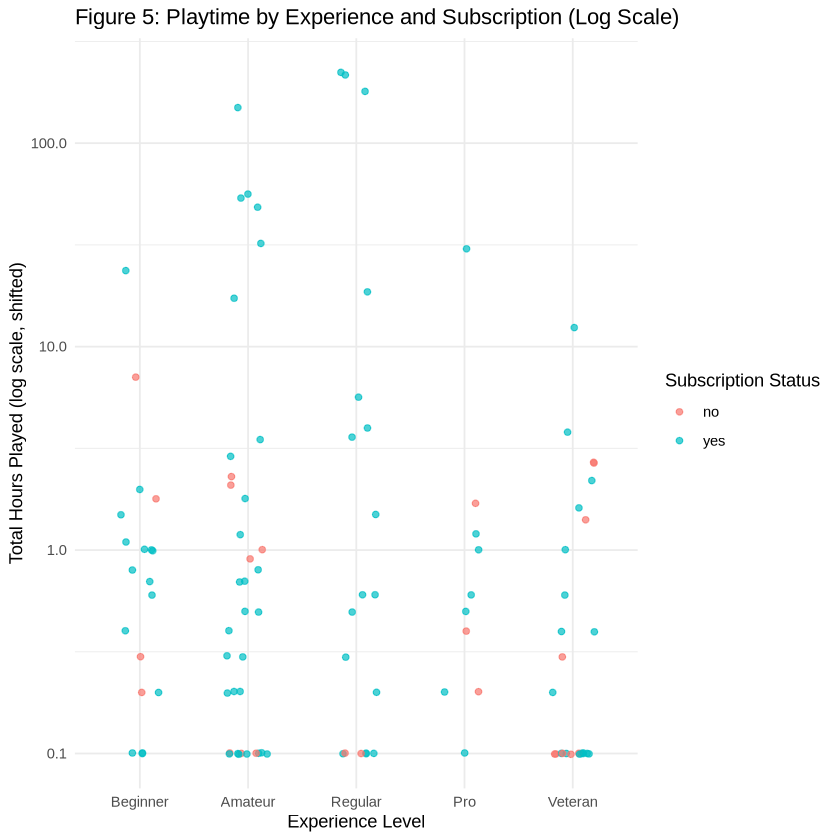

In [8]:
# FIGURE 1
experience_plot <- players_wrangled |>
ggplot(aes(x = experience, fill = experience)) +
  geom_bar() +
  labs(
    title = "Figure 1: Distribution of Player Experience Levels",
    x = "Experience Level",
    y = "Number of Players"
  )
experience_plot

# FIGURE 2
subscribed_summarised <- players_wrangled |>
  group_by(subscribe) |>
  summarise(mean_hours = mean(played_hours, na.rm = TRUE))

subscribed_plot <- subscribed_summarised |>  

ggplot(aes(x = subscribe, y = mean_hours, fill = subscribe)) +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_text(aes(label = round(mean_hours, 2)), vjust = -0.5, size = 4) +
  labs(
    title = "Figure 2: Average Playtime by Subscription Status",
    x = "Subscription Status",
    y = "Average Played Hours (hours)")
subscribed_plot

# FIGURE 3
age_hours_plot <- players_wrangled |>
  ggplot(aes(x = age, y = played_hours, colour = subscribe)) +
  geom_point(alpha = 1) +
scale_y_log10() +
  labs(
    title   = "Figure 3: Age vs Total Hours Played by Subscription Status (log scale)",
    x       = "Age (years)",
    y       = "Total Hours Played (hours)",
    colour  = "Subscription Status"
  ) +
  theme_minimal()

age_hours_plot


# FIGURE 4
experience_subscription_summary <- players_wrangled |>
  group_by(experience) |>
  summarise(
    subscription_rate = mean(as.character(subscribe) == 'yes'),
    number_of_players = n(),
    .groups = "drop"
  )

subscription_rate_plot <- experience_subscription_summary |>
  ggplot(aes(x = experience, y = subscription_rate, fill = experience)) +
  geom_col(width = 0.6, alpha = 0.9) +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = "Figure 4: Subscription Rate by Player Experience Level",
    x     = "Experience Level",
    y     = "Subscription Rate",
    fill  = "Experience Level") +
  theme_minimal()


subscription_rate_plot

# FIGURE 5
playtime_experience_plot <- players_wrangled |>
  filter(played_hours != 0) |>  
  ggplot(aes(x = experience, y = played_hours, colour = subscribe)) +
  geom_jitter(alpha = 0.7, width = 0.2) +
  scale_y_log10() +
  labs(
    title = "Figure 5: Playtime by Experience and Subscription (Log Scale)",
    x = "Experience Level",
    y = "Total Hours Played (log scale, shifted)",
    colour = "Subscription Status") + theme_minimal()

playtime_experience_plot

To better understand patterns within the dataset and explore potential relationships relevant to player engagement, we produced a series of visualizations, each addressing a different aspect of our research question. These figures helped reveal how experience level, subscription status, and playtime differ across the player base.

Figure 1 displays the Distribution of Player Experience Levels, showing how players are spread across categories such as “Beginner,” “Intermediate,” “Advanced,” and “Expert.” This bar chart highlights that the dataset is not evenly distributed, with certain experience levels (Amateur &  Veteran) being more common. Understanding this imbalance is important because it affects how much each experience group contributes to overall engagement trends.

Figure 2 presents the Average Playtime by Subscription Status. By summarizing mean hours played for subscribed and unsubscribed players, this visualization provides an early indication of how subscription may relate to engagement. Subscribed players show notably higher average playtime, suggesting that subscription status is associated with more consistent or longer-term play patterns.

Figure 3 displays Age vs Total Hours Played (log scale), coloured by subscription status. This scatterplot highlights the wide variability in playtime across age groups and shows that subscribers generally appear at higher playtime values. The log scale makes patterns visible that would otherwise be hidden by outliers. While age itself does not show a strong linear relationship with playtime, the visualization suggests that subscription status is a more influential factor than age in determining player engagement.

Figure 4 summarizes how likely players of each experience group are to subscribe. This provides insight into whether more experienced players are more willing to invest in the game. If higher-experience groups subscribe at higher rates, this supports experience as a meaningful predictor for modeling.

Figure 5  shows the distribution of played hours across experience levels and subscription groups, after filtering out players with 0 hours. Using points on a log-scaled y-axis, this visualization highlights how playtime varies within and between experience categories. Subscribers consistently cluster at higher playtime values across most experience levels, reinforcing the pattern that subscription status is strongly associated with greater engagement.

Together, the five visualizations provide a clear picture of how experience level, subscription status, age, and playtime interact within the dataset. The experience distribution (Figure 1) shows that players are unevenly spread across experience levels, which helps contextualize later comparisons. Figures 2 and 3 consistently demonstrate that subscribed players engage with the game far more than non-subscribers, both in terms of average playtime and total hours played across age groups. Figures 4 and 5 further reveal that experience also plays an important role: subscription rates vary across experience levels, and subscribers consistently appear at higher playtime values within nearly every experience category. Overall, these visual patterns highlight strong relationships between subscription status, experience, and engagement, and they motivate the need for predictive modeling in the next stage of the analysis.

### Data Analysis

In this section, we build and evaluate a classification model to determine whether player characteristics can be used to predict subscription status. Guided by the patterns identified in the visualization section, specifically the strong relationships between playtime, experience level, and subscription—we apply a k-nearest neighbours (k-NN) model. k-NN is an appropriate choice for this project because it is a simple, interpretable model that classifies observations based on similarity, making it well suited for behavioural data such as hours played and level of experience. The analysis below includes data splitting, preprocessing, model tuning, model fitting, and performance evaluation.

neighbors,.config
<int>,<chr>
25,Preprocessor1_Model25


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7627119
precision,binary,0.7500000


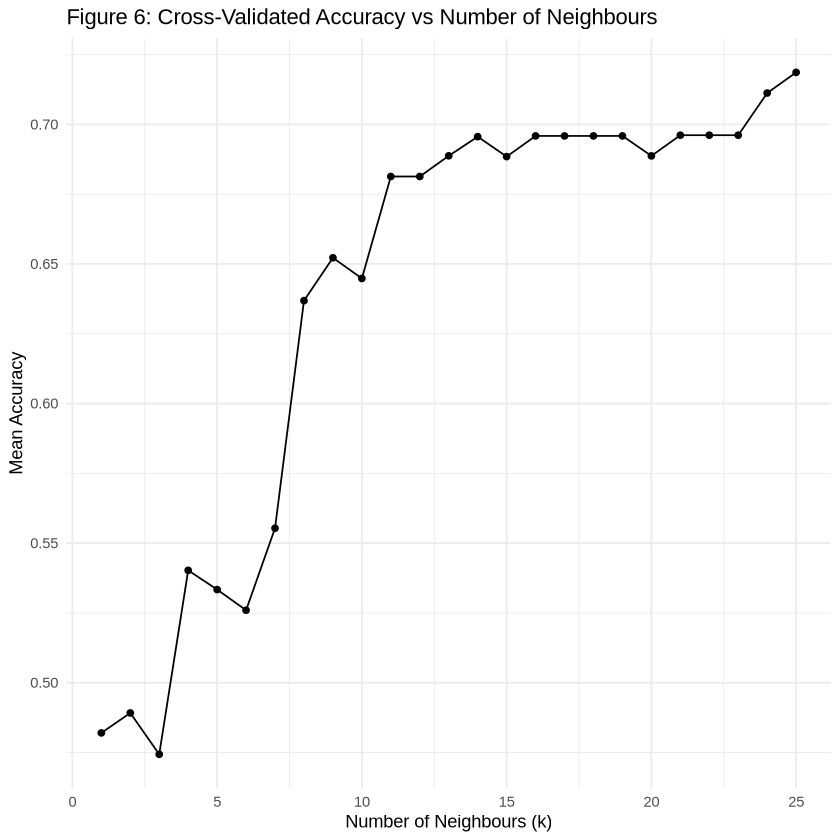

In [5]:

players_split <- players_wrangled |>
  initial_split(prop = 0.7, strata = subscribe)

players_train <- training(players_split)
players_test  <- testing(players_split)



players_recipe <- recipe(subscribe ~ experience + age + played_hours,
                         data = players_train) |>
  step_integer(experience, zero_based = TRUE) |>
  step_normalize(all_predictors())




knn_spec <- nearest_neighbor(
  mode = "classification",
  neighbors = tune()) |>
  set_engine("kknn")

knn_workflow <- workflow() |>
  add_recipe(players_recipe) |>
  add_model(knn_spec)




players_folds <- vfold_cv(players_train, v = 5, strata = subscribe)

k_grid <- grid_regular(neighbors(range = c(1, 25)), levels = 25)

knn_tuned <- tune_grid(
  knn_workflow,
  resamples = players_folds,
  grid = k_grid,
  metrics = metric_set(accuracy)
)


#### 6. ACCURACY PLOT (FIGURE 6) ####

accuracy_plot <- knn_tuned |>
  collect_metrics() |>
  filter(.metric == "accuracy") |>
  ggplot(aes(x = neighbors, y = mean)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Figure 6: Cross-Validated Accuracy vs Number of Neighbours",
    x = "Number of Neighbours (k)",
    y = "Mean Accuracy"
  ) +
  theme_minimal()

accuracy_plot


#### 7. FINAL MODEL ####

best_k <- knn_tuned |> select_best("accuracy")
best_k

final_knn_workflow <- knn_workflow |>
  finalize_workflow(best_k)

final_knn_fit <- final_knn_workflow |> fit(players_train)


#### 8. TEST PREDICTIONS (NO MORE ERROR) ####

test_predictions <- predict(final_knn_fit, players_test) |>
  bind_cols(players_test |> select(subscribe))

test_metrics <- test_predictions |>
  metric_set(accuracy, precision)(
    truth = subscribe,
    estimate = .pred_class
  )

test_metrics


### Discussion & Summary


Our data analysis using a k-nearest neighbours classification model revealed that the optimal value of k varied noticeably each time the model was retrained, and the resulting accuracy and precision also shifted across runs. This instability suggests that the model’s performance is highly sensitive to the specific partitioning of the training and testing sets, which indicates that the relationship between age, experience level, playtime, and subscription status is not strong or consistent enough for the model to make reliable predictions. Alternatively, this may also come from our sample size being too small to be able to give meaningful or consistently accurate results.

In other words, although our exploratory visualizations suggested that subscribed players tend to play more hours and appear somewhat differently across experience levels, the inconsistency of the optimal k and the fluctuating performance metrics show that the underlying patterns are not solid or deterministic. This was somewhat unexpected, as we initially anticipated a clearer, more stable relationship between these engagement indicators (such as total hours played) and the likelihood of subscribing. The fact that our model does not consistently identify strong predictive power suggests that these behavioural variables alone cannot reliably explain or predict subscription decisions, and therefore we are unable to confidently claim that there is a strong connection between these factors and subscription status. More specifically, we could assume that either some of these factors don't play a role in finding subscription status, or that not enough factors are being looked at.

These findings have meaningful implications. If playtime, experience, and age together do not predict subscription reliably, then game designers or platform managers seeking to increase subscription rates may need to consider additional variables not included in our dataset. The lack of a stable predictive pattern also highlights the complexity of user behaviour, showing that subscribing may depend on factors that cannot be inferred from gameplay metrics alone. Future analyses could explore whether adding more behavioural data improves the model’s ability to detect meaningful trends. Other future analyses could explore these 3 predictors individually to find a pattern within subscription status, rather than looking at all 3 together as we did in this project.

It also raises broader questions about how subscription decisions form: Do players subscribe because they are already committed, or does subscribing change their engagement? Are certain personality traits or external incentives more influential than in-game behaviour? Ultimately, the variability and weakness of our model’s predictive power emphasize the need for more detailed data and more sophisticated modelling approaches to fully understand what drives subscription behaviour.